In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.manifold import TSNE

In [37]:
data = pd.read_csv('/content/drive/MyDrive/SMT6/_data_miningg/UTS/Hypertension.csv', sep=';')

data.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Risk
0,1,39,0,0.0,0.0,0,195.0,106,70,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,250.0,121,81,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,245.0,127.05.00,80,25.34.00,75.0,70.0,0
3,0,61,1,30.0,0.0,0,225.0,150,95,28.58.00,65.0,103.0,1
4,0,46,1,23.0,0.0,0,285.0,130,84,23.01,85.0,85.0,0


## PREPROCESSING

In [38]:
print("\nRingkasan Dataset:")
print(f"Jumlah Fitur: {data.shape[1]}")
print(f"Jumlah data: {data.shape[0]}")
print(f"Jumlah Kelas: {data['Risk'].nunique()} (0 = Tidak ada gejala hipertensi, 1 = Ada gejala hipertensi)")
print("\nInformasi Dataset:")
print(data.info())


Ringkasan Dataset:
Jumlah Fitur: 13
Jumlah data: 4240
Jumlah Kelas: 2 (0 = Tidak ada gejala hipertensi, 1 = Ada gejala hipertensi)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   male           4240 non-null   int64  
 1   age            4240 non-null   int64  
 2   currentSmoker  4240 non-null   int64  
 3   cigsPerDay     4211 non-null   float64
 4   BPMeds         4187 non-null   float64
 5   diabetes       4240 non-null   int64  
 6   totChol        4190 non-null   float64
 7   sysBP          4240 non-null   object 
 8   diaBP          4240 non-null   object 
 9   BMI            4221 non-null   object 
 10  heartRate      4239 non-null   float64
 11  glucose        3852 non-null   float64
 12  Risk           4240 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 430.8+ KB
None


In [39]:
data.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,diabetes,totChol,heartRate,glucose,Risk
count,4240.000000,4240.000000,4240.000000,4211.000000,4187.000000,4240.000000,4190.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,0.494104,9.005937,0.029615,0.025708,236.699523,75.878981,81.963655,0.310613
std,0.495027,8.572942,0.500024,11.922462,0.169544,0.158280,44.591284,12.025348,23.954335,0.462799
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,107.000000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,206.000000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,234.000000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,263.000000,83.000000,87.000000,1.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,696.000000,143.000000,394.000000,1.000000


In [40]:
# Periksa missing values
print("\nCek Missing Values:")
print(data.isnull().sum())


Cek Missing Values:
male               0
age                0
currentSmoker      0
cigsPerDay        29
BPMeds            53
diabetes           0
totChol           50
sysBP              0
diaBP              0
BMI               19
heartRate          1
glucose          388
Risk               0
dtype: int64


In [41]:
# Menghilangkan baris dengan missing values
data_cleaned = data.dropna()

print("\nJumlah data setelah menghilangkan missing values:")
print(data_cleaned.shape[0])

print("\nCek Missing Values setelah di drop:")
print(data_cleaned.isnull().sum())


Jumlah data setelah menghilangkan missing values:
3751

Cek Missing Values setelah di drop:
male             0
age              0
currentSmoker    0
cigsPerDay       0
BPMeds           0
diabetes         0
totChol          0
sysBP            0
diaBP            0
BMI              0
heartRate        0
glucose          0
Risk             0
dtype: int64


In [42]:
# Encode fitur kategorikal
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['sysBP', 'diaBP', 'BMI']
le = LabelEncoder()
for col in categorical_cols:
    data_cleaned[col] = le.fit_transform(data_cleaned[col])

<ipython-input-42-2934864109>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col] = le.fit_transform(data_cleaned[col])
<ipython-input-42-2934864109>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[col] = le.fit_transform(data_cleaned[col])
<ipython-input-42-2934864109>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [43]:
print("\n info tipe data setelah encode:")
data.info()
print("\n detail isi setelah encode:")
data.head()


 info tipe data setelah encode:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   male           4240 non-null   int64  
 1   age            4240 non-null   int64  
 2   currentSmoker  4240 non-null   int64  
 3   cigsPerDay     4211 non-null   float64
 4   BPMeds         4187 non-null   float64
 5   diabetes       4240 non-null   int64  
 6   totChol        4190 non-null   float64
 7   sysBP          4240 non-null   object 
 8   diaBP          4240 non-null   object 
 9   BMI            4221 non-null   object 
 10  heartRate      4239 non-null   float64
 11  glucose        3852 non-null   float64
 12  Risk           4240 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 430.8+ KB

 detail isi setelah encode:


,male,age,currentSmoker,cigsPerDay,BPMeds,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Risk
0,1,39,0,0.0,0.0,0,195.0,106,70,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,250.0,121,81,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,245.0,127.05.00,80,25.34.00,75.0,70.0,0
3,0,61,1,30.0,0.0,0,225.0,150,95,28.58.00,65.0,103.0,1
4,0,46,1,23.0,0.0,0,285.0,130,84,23.01,85.0,85.0,0


## **SCALING DATA**

In [44]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target dari data_cleaned
X = data_cleaned.drop('Risk', axis=1)
y = data_cleaned['Risk']

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [34]:
# Visualisasi sebaran data
plt.figure(figsize=(15, 10))
sns.pairplot(pd.concat([X_scaled, y], axis=1), hue='Risk', palette='viridis')
plt.suptitle('Fitur Terstandarisasi', y=1.02)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## **FEATURE ENGINEERING**

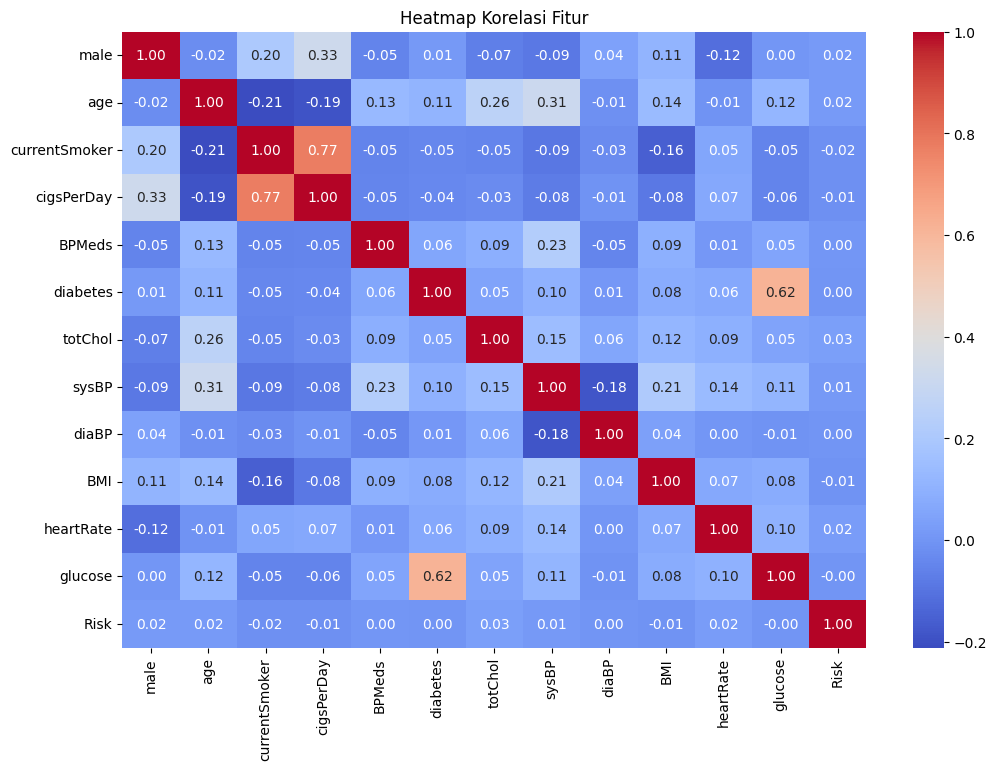

In [45]:
# Analisis korelasi
plt.figure(figsize=(12, 8))
corr_matrix = pd.concat([X_scaled, y], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur')
plt.show()

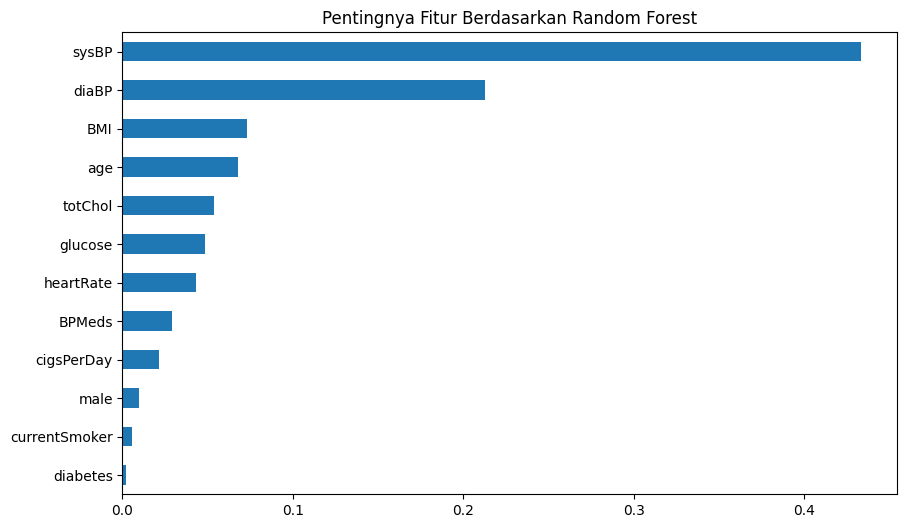

In [46]:
# Seleksi fitur dengan Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
feature_importances = pd.Series(rf.feature_importances_, index=X_scaled.columns)
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind='barh')
plt.title('Pentingnya Fitur Berdasarkan Random Forest')
plt.show()

In [47]:
# Seleksi 5 fitur terbaik
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_scaled, y)
selected_features = X_scaled.columns[selector.get_support()]
print("\n5 Fitur Terpilih:")
print(selected_features)


5 Fitur Terpilih:
Index(['age', 'BPMeds', 'totChol', 'sysBP', 'BMI'], dtype='object')


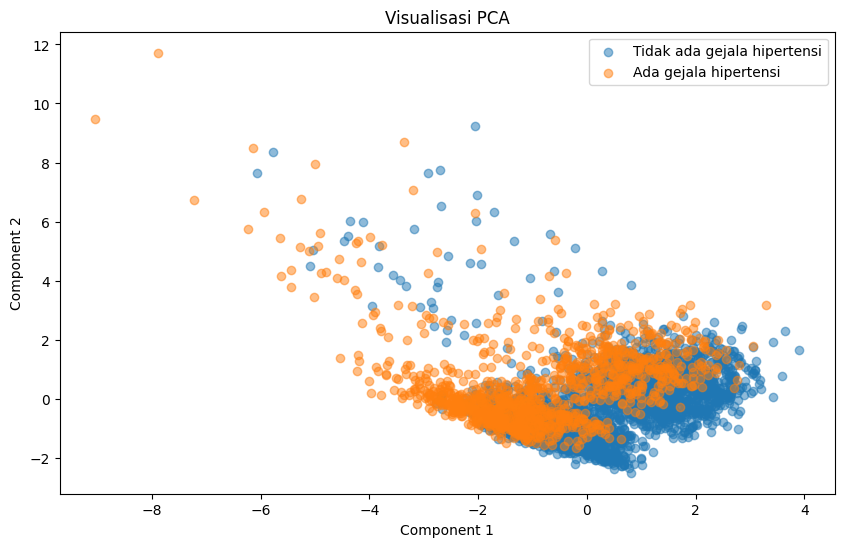

In [48]:
# Reduksi dimensi dengan PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.5, label='Tidak ada gejala hipertensi')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.5, label='Ada gejala hipertensi')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Visualisasi PCA')
plt.legend()
plt.show()

In [49]:
# Gunakan fitur terpilih untuk modeling
X_selected = X_scaled[selected_features]

## **KLASIFIKASI**

In [50]:
# Bagi data menjadi train dan test (80:20)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pisahkan data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi model
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# Latih model
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Prediksi
knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

In [51]:
# Evaluasi
def evaluate_model(model_name, y_true, y_pred):
    print(f"\nEvaluasi {model_name}:")
    print(f"Akurasi: {accuracy_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model("k-NN", y_test, knn_pred)
evaluate_model("SVM", y_test, svm_pred)
evaluate_model("Decision Tree", y_test, dt_pred)


Evaluasi k-NN:
Akurasi: 0.8482

Confusion Matrix:
[[464  53]
 [ 61 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       517
           1       0.77      0.74      0.75       234

    accuracy                           0.85       751
   macro avg       0.82      0.82      0.82       751
weighted avg       0.85      0.85      0.85       751


Evaluasi SVM:
Akurasi: 0.8668

Confusion Matrix:
[[474  43]
 [ 57 177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       517
           1       0.80      0.76      0.78       234

    accuracy                           0.87       751
   macro avg       0.85      0.84      0.84       751
weighted avg       0.87      0.87      0.87       751


Evaluasi Decision Tree:
Akurasi: 0.8282

Confusion Matrix:
[[450  67]
 [ 62 172]]

Classification Report:
              precision    recall  f1-score 

## **VISUALISASI**

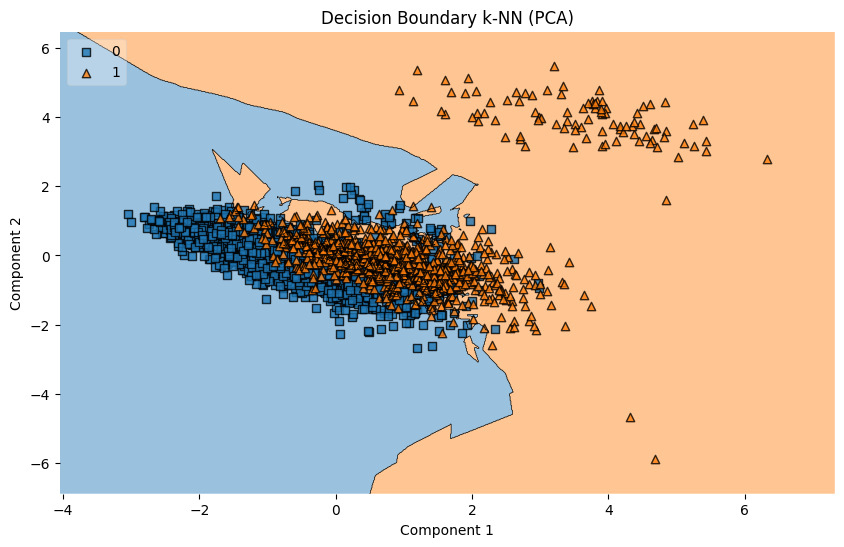

In [52]:
# Gunakan PCA untuk visualisasi 2D
from mlxtend.plotting import plot_decision_regions

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Latih ulang model dengan data PCA
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_train_pca, y_train.values, clf=knn_pca, legend=2)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Decision Boundary k-NN (PCA)')
plt.show()

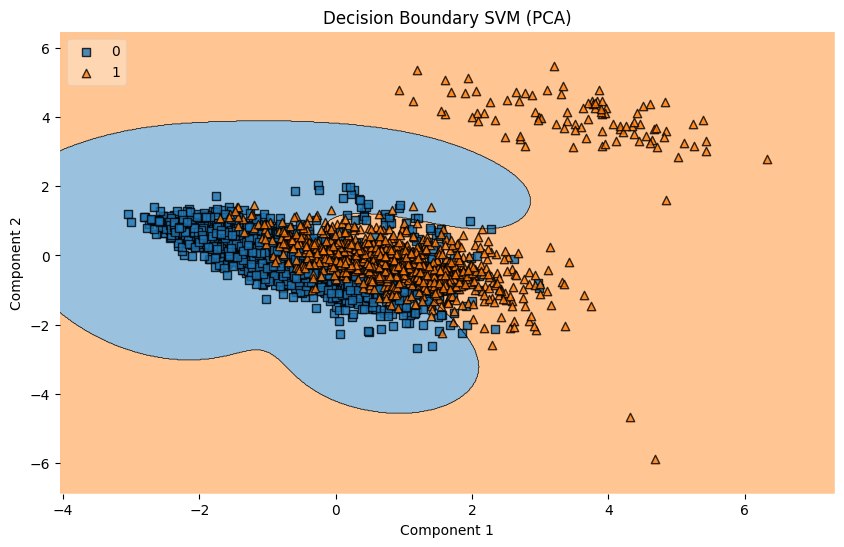

In [53]:
import matplotlib.pyplot as plt
# Latih ulang model SVM dengan data PCA
svm_pca = SVC(kernel='rbf', C=1.0, random_state=42)
svm_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_train_pca, y_train.values, clf=svm_pca, legend=2)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Decision Boundary SVM (PCA)')
plt.show()

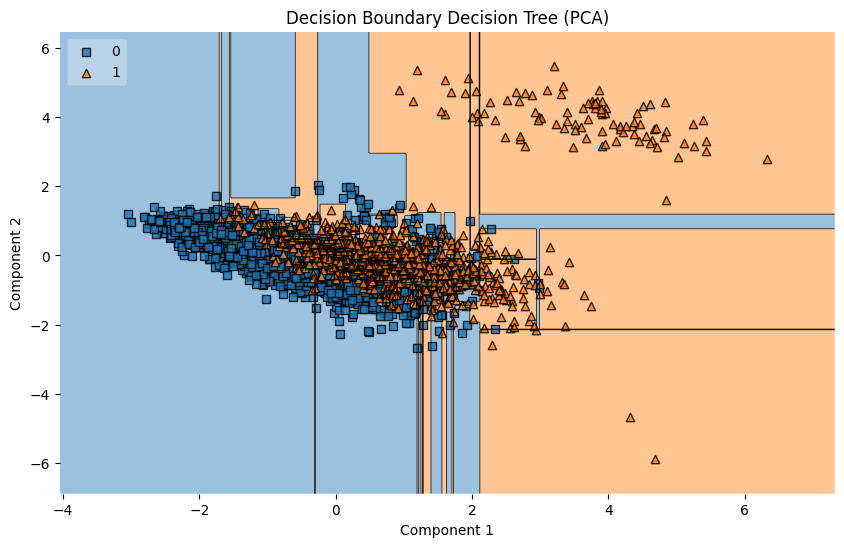

In [55]:
# Gunakan PCA untuk visualisasi 2D
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt # Ensure matplotlib.pyplot is imported

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Latih ulang model dengan data PCA
dt = DecisionTreeClassifier(random_state=42)
# Fit the Decision Tree model (assigned to 'dt') to the PCA-transformed data
dt.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
# Use the fitted 'dt' model for plotting
plot_decision_regions(X_train_pca, y_train.values, clf=dt, legend=2)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Decision Boundary Decision Tree (PCA)')
plt.show()